# imports

In [17]:
import cv2
from correspondance import find_correspondences,plot_correspondences
from homography import compute_homography, verify_homography
from corners import get_book_corners_in_frame, draw_book_outline
from crop import crop_ar_frame
import matplotlib.pyplot as plt
from overlay import display_frame, overlay_ar_frame

### 1- Augmented Reality with Planar Homographies

In [18]:
book_img   = cv2.imread("materials/cv_cover.jpg")          # static book cover image
book_cap   = cv2.VideoCapture("materials/book.mov")
ar_cap     = cv2.VideoCapture("materials/ar_source.mov")

ret1, book_frame = book_cap.read()           # first frame of book video
ret2, ar_frame   = ar_cap.read()             # first frame of AR source video

if not (ret1 and ret2):
        raise IOError("Could not read video frames — check file paths.")


### 1.1- Getting Correspondences

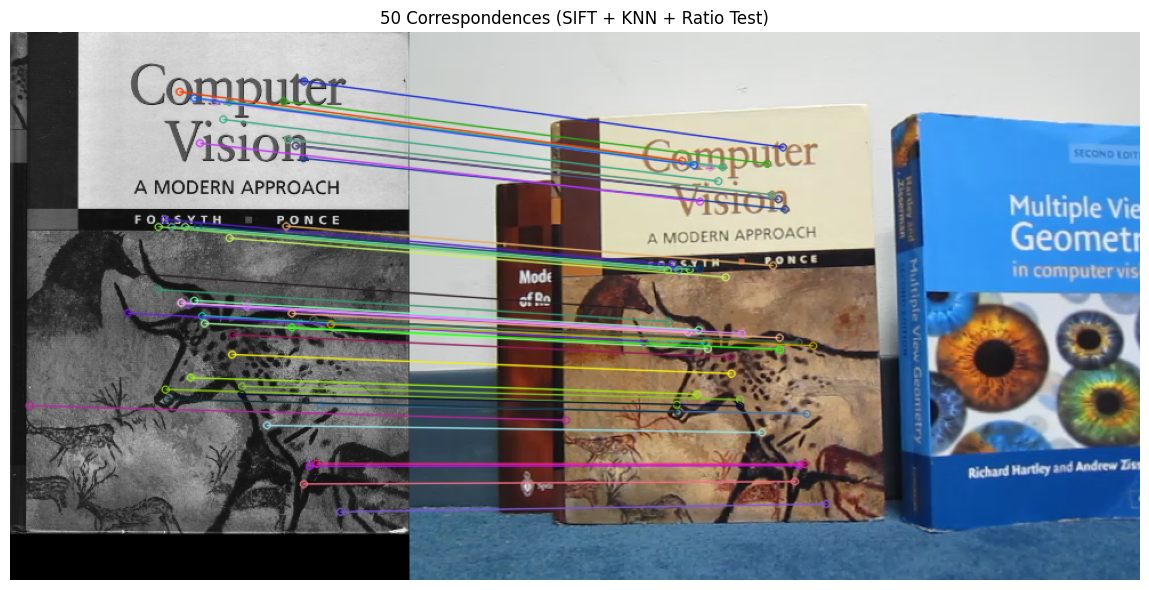

In [19]:
pts1, pts2, kp1, kp2, good = find_correspondences(book_img, book_frame, n=50)
plot_correspondences(book_img, book_frame, kp1, kp2, good)

#### 2.2 - Compute the Homography Parameters

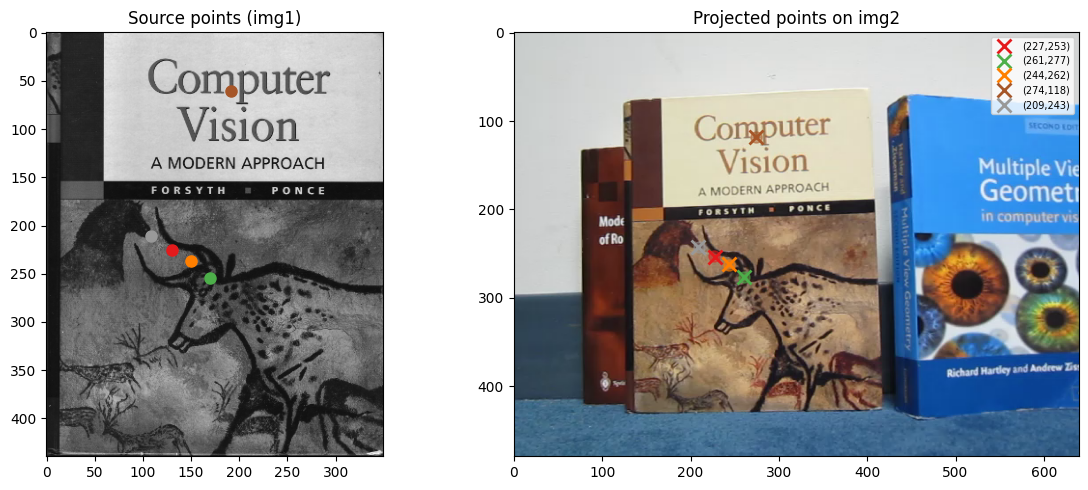

In [20]:
H = compute_homography(pts1, pts2)
verify_homography(H, pts1, pts2, book_img, book_frame)

#### 1.3 - Calculate Book Coordinates

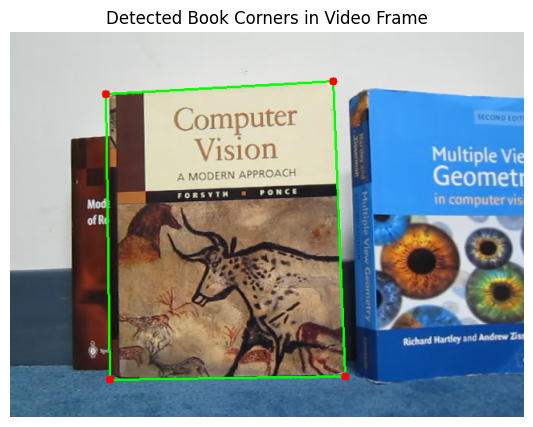

In [21]:
book_corners = get_book_corners_in_frame(H, book_img)
vis = draw_book_outline(book_frame.copy(), book_corners)
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Detected Book Corners in Video Frame")
plt.axis("off")
plt.show()

#### 1.4 - Crop Ar Video Frames

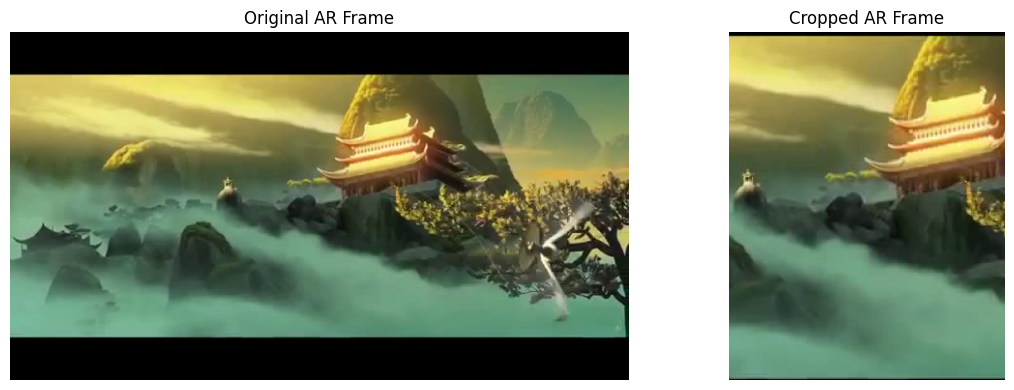

In [22]:
cropped_ar = crop_ar_frame(ar_frame, book_corners) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(ar_frame,   cv2.COLOR_BGR2RGB)); axes[0].set_title("Original AR Frame")
axes[1].imshow(cv2.cvtColor(cropped_ar, cv2.COLOR_BGR2RGB)); axes[1].set_title("Cropped AR Frame")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

#### 1.5 - Overlay the First Frame of the Two videos

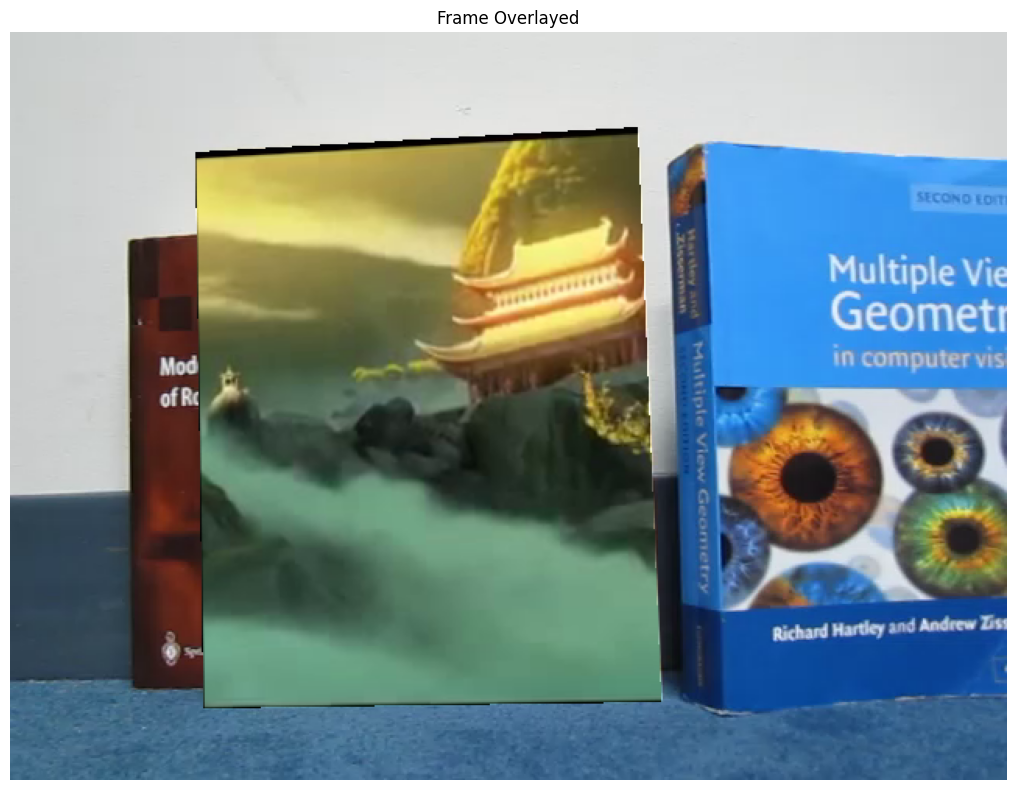

In [23]:
first_overlayed_frame = overlay_ar_frame(book_frame, cropped_ar, book_corners)
display_frame(first_overlayed_frame)
book_cap.release()
ar_cap.release()

#### 1.6 Creating AR Application

In [24]:
book_img = cv2.imread('materials/cv_cover.jpg')
book_cap = cv2.VideoCapture('materials/book.mov')
ar_cap = cv2.VideoCapture('materials/ar_source.mov')

# Get video properties for the writer
w = int(book_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(book_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(book_cap.get(cv2.CAP_PROP_FPS))
out = cv2.VideoWriter('final_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

print("Starting video processing...")

while True:
    ret1, book_frame = book_cap.read()
    ret2, ar_frame = ar_cap.read()
    
    if not ret1 or not ret2:
        break
    
    pts1, pts2, _, _, _ = find_correspondences(book_img, book_frame, n=50)
    H = compute_homography(pts1, pts2)
    projected_corners = get_book_corners_in_frame(H, book_img) 
    cropped_ar = crop_ar_frame(ar_frame, projected_corners)
    final_frame = overlay_ar_frame(book_frame, cropped_ar, projected_corners)
    out.write(final_frame)

book_cap.release()
ar_cap.release()
out.release()
print("Video saved as final_output.mp4")

Starting video processing...
Video saved as final_output.mp4
